In [179]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI

"""I use a .env file that has my API keys"""
import os
from dotenv import load_dotenv

load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

Making a simple AI app that tells us what the weather is at a specific country
here is the our simple diagram

**You can view the state diagram in the README FILE**

In [180]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph = StateGraph(State)

In [181]:
@tool
def get_weather(location: str):
    """We call this to get the weather"""
    if location.lower():
        return "its cold"
    else:
        return "its hot"

tools = [get_weather]

In [ ]:
llm = ChatGoogleGenerativeAI(
    google_api_key=GEMINI_API_KEY,
    model="gemini-3.1-flash-lite",
)

llm_with_tools = llm.bind_tools(tools)

In [183]:
tool_node = ToolNode(tools)

graph.add_node("tool_node", tool_node)

In [184]:
def prompt_node(state: State) -> State:
    new_message = llm_with_tools.invoke(state['messages'])
    return {"messages": [new_message]}

graph.add_node("prompt_node", prompt_node)

In [185]:
def conditional_edge(state: State) -> Literal['tool_node', '__end__']:
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        return "tool_node"
    else: 
        return "__end__"

graph.add_conditional_edges (
    'prompt_node',
    conditional_edge
)

graph.add_edge("tool_node", "prompt_node")
graph.set_entry_point("prompt_node")

In [186]:
APP = graph.compile()

new_state = APP.invoke({"messages": ["Whats the weather in Egypt?"]})
print(new_state["messages"][-1].content)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use models/gemini-3.6-flash for the latest features and improvements.', 'status': 'NOT_FOUND'}}

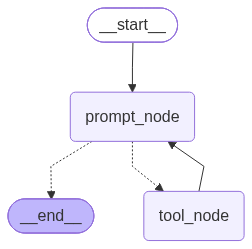

In [ ]:
"""Displaying the graph"""
from IPython.display import Image, display
display(Image(APP.get_graph().draw_mermaid_png()))